# Setup

In [1]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import sdevelo
import warnings
import torch

(Working on SDEvelo 0.2.12)
2026-04-13 11:46:34


In [2]:
# Check if GPU is available
print(torch.cuda.is_available())

True


In [3]:
# Scanpy plotting setup

figure_size = (4, 4)
scanpy.set_figure_params(dpi=100, dpi_save=300, figsize=figure_size, color_map="plasma")

warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

In [ ]:
# Read input file
working_directory = "RNA Sequencing Data/"
adata = scanpy.read_h5ad(working_directory+"/splice_counts.h5ad")

# Or read saved file for further analysis
# adata = scanpy.read_h5ad(working_directory+"/velocity_sdevelo.h5ad")

# Set sample colors
sample_colors = [
    "#9e9e9e",
    "#dfb83a", 
    "#df8b2b",
    "#da5b20",
    "#bb401a",
    "#700000",
    "#4ceeb8",
    "#29cadf",
    "#308ecc",
    "#034c88",
    "#000B6E",
    '#0a652c'
]
adata.uns["sample_colors"] = sample_colors

print(adata)

AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'seurat_clusters'
    var: 'ensemble_ids', 'gene_symbol'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


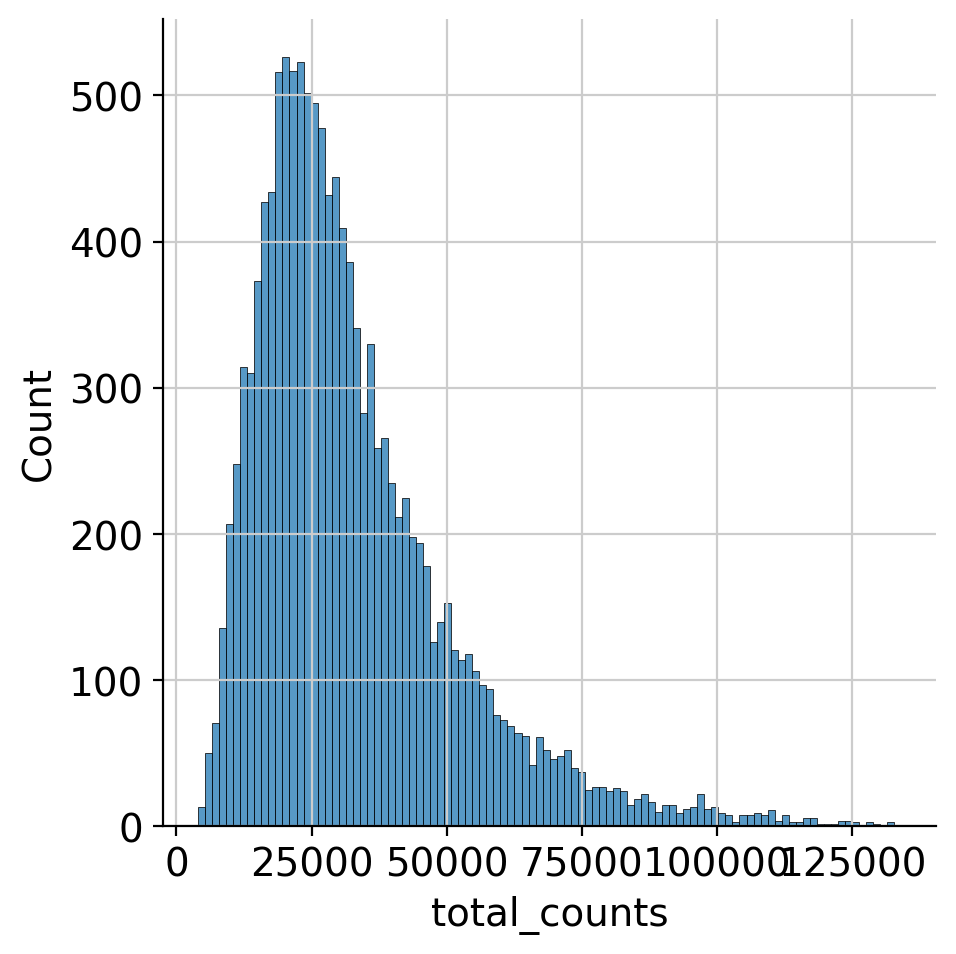

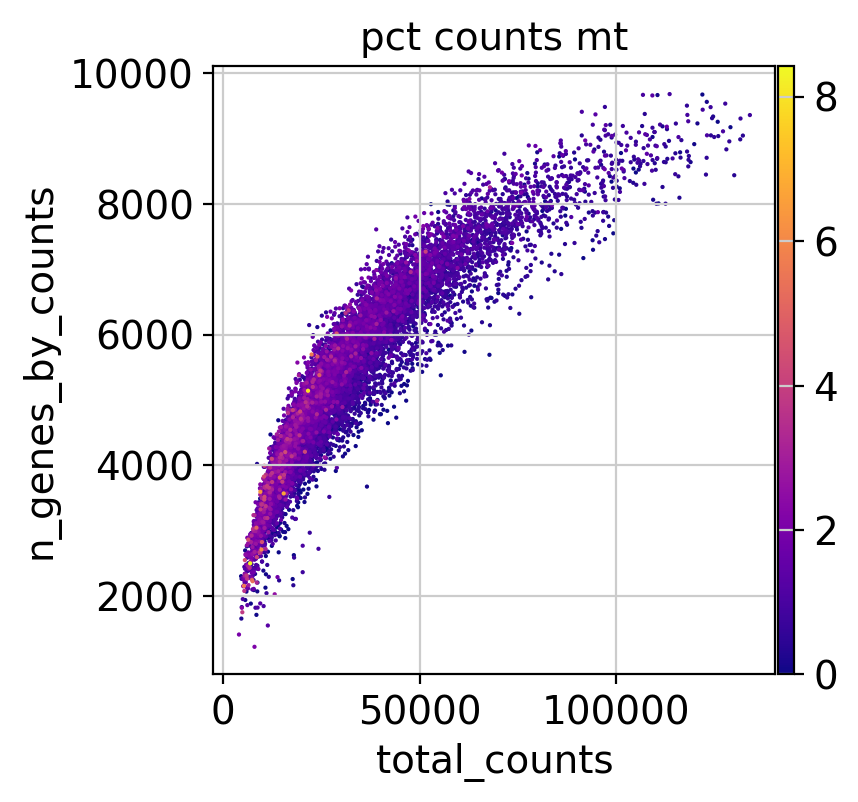

In [10]:
# Quality control

adata.var["mt"] = adata.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata, inplace=True, percent_top=[], log1p=False
)
histogram = seaborn.displot(adata.obs["total_counts"], bins=100, kde=False)
scatter = scanpy.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

View of AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'seurat_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


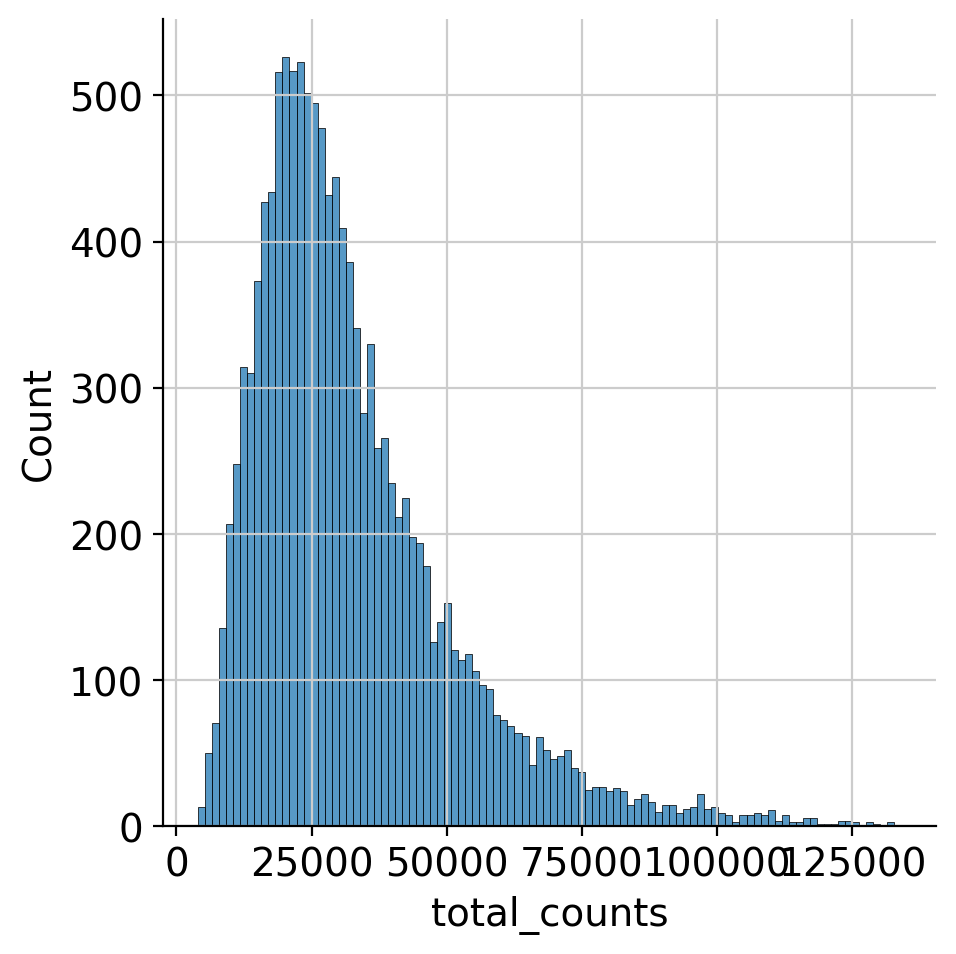

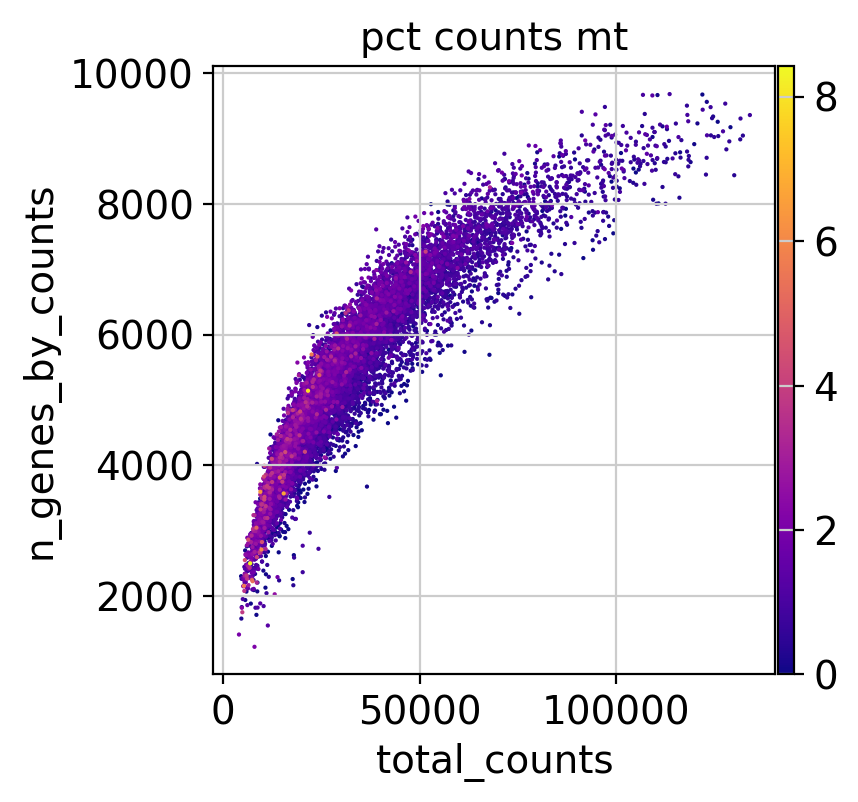

In [11]:
# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata.obs["n_genes_by_counts"] >= 200)*(adata.obs['total_counts'] <= 150000)*(adata.obs['pct_counts_mt'] < 10)
adata = adata[included_cells]
print(adata)
histogram = seaborn.displot(adata.obs["total_counts"], bins=100, kde=False)
scatter = scanpy.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

All cells are included because of the filtering when creating the Anndata object.

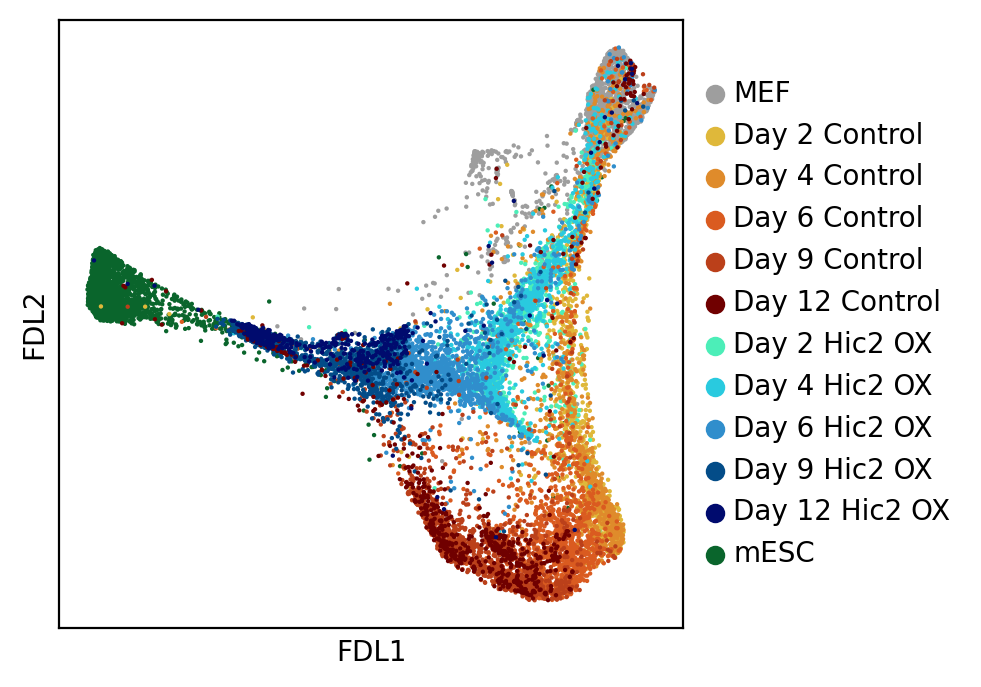

In [24]:
# Plot FDL

axis = scanpy.pl.embedding(basis='fdl', adata=adata, color="sample", size=10, title="", legend_fontsize=10, show=False)
axis.set_xlabel("FDL1", fontsize=10)
axis.set_ylabel("FDL2", fontsize=10)
figure = pyplot.gcf()
pyplot.show()
figure.savefig("Graphs/samples.png", bbox_inches="tight", dpi=300)

In [19]:
# Define SDEvelo arguments
args = sdevelo.Config()
args.vis_key = "X_fdl"
args.vis_type_col = "sample"
args.scv_n_jobs = 32
args.n_gene = 2000
args.seed = 0
args.cuda_device = 0

In [20]:
# Train SDEvelo model
model = sdevelo.SDENN(args, adata)
adata = model.train(600)

cuda


Filtered out 35658 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
Using scVelo version 0.3.3


/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
5000
Epoch: 0, Loss: 0.843, alpha: 12.90, beta: 11.41, gamma: 1.16, s1: 0.010, s2: 0.010,  t_m: 0.671,  u_shift: 0.000,  s_shift: -0.013
Epoch: 50, Loss: 0.630, alpha: 5.07, beta: 9.44, gamma: 1.56, s1: 0.014, s2: 0.010,  t_m: 0.761,  u_shift: 0.000,  s_shift: -0.043
Epoch: 100, Loss: 0.504, alpha: 16.25, beta: 26.99, gamma: 7.99, s1: 0.013, s2: 0.010,  t_m: 0.734,  u_shift: 0.000,  s_shift: -0.001
Epoch: 150, Loss: 0.450, alpha: 25.37, beta: 44.57, gamma: 12.98, s1: 0.010, s2: 0.015,  t_m: 0.792,  u_shift: 0.000,  s_shift: 0.069
Epoch: 200, Loss: 0.412, alpha: 35.15, beta: 61.98, gamma: 17.71, s1: 0.010, s2: 0.026,  t_m: 0.815,  u_shift: 0.000,  s_shift: 0.100
Epoch: 250, Loss: 0.390, alpha: 36.20, beta: 64.09, gamma: 18.24, s1: 0.021, s2: 0.010,  t_m: 0.818,  u_shift: 0.000,  s_shift: 0.100
Epoch: 300, Loss: 0.390, alpha: 37.66, beta: 66.70, g

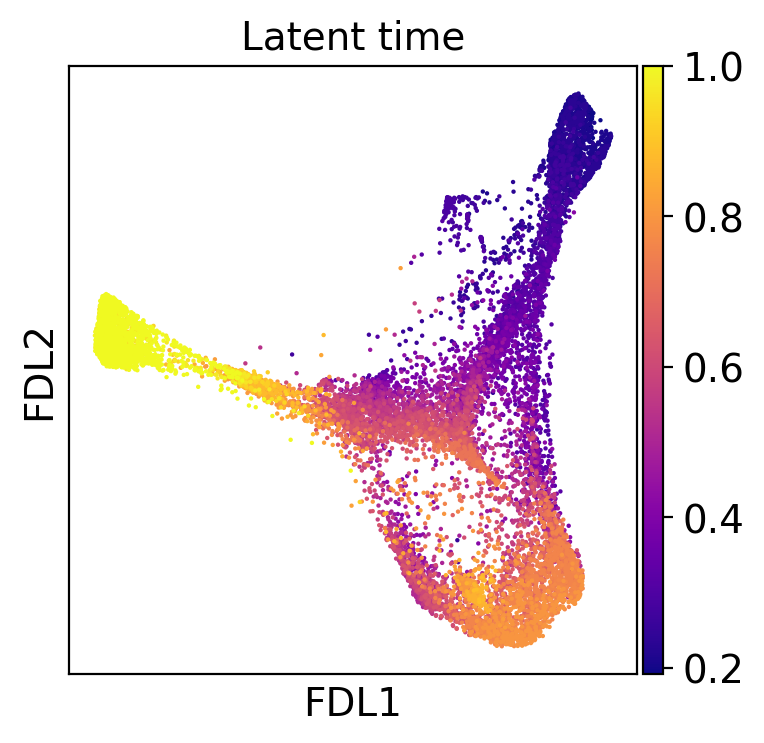

In [25]:
# Plot latent time
axis = scanpy.pl.embedding(basis='fdl', adata=adata, color=["latent_time"], size=10, title=["Latent time"], show=False)
axis.set_xlabel("FDL1")
axis.set_ylabel("FDL2")
figure = pyplot.gcf()
pyplot.show()
figure.savefig("Graphs/latent_time.png", bbox_inches="tight", dpi=300)

In [75]:
# Velocity cosine correlations
scvelo.tl.velocity_graph(adata, vkey="sde_velocity", n_jobs=16)

computing velocity graph (using 16/32 cores)


  0%|          | 0/12791 [00:00<?, ?cells/s]

/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=232137) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:21) --> added 
    'sde_velocity_graph', sparse matrix with cosine correlations (adata.uns)


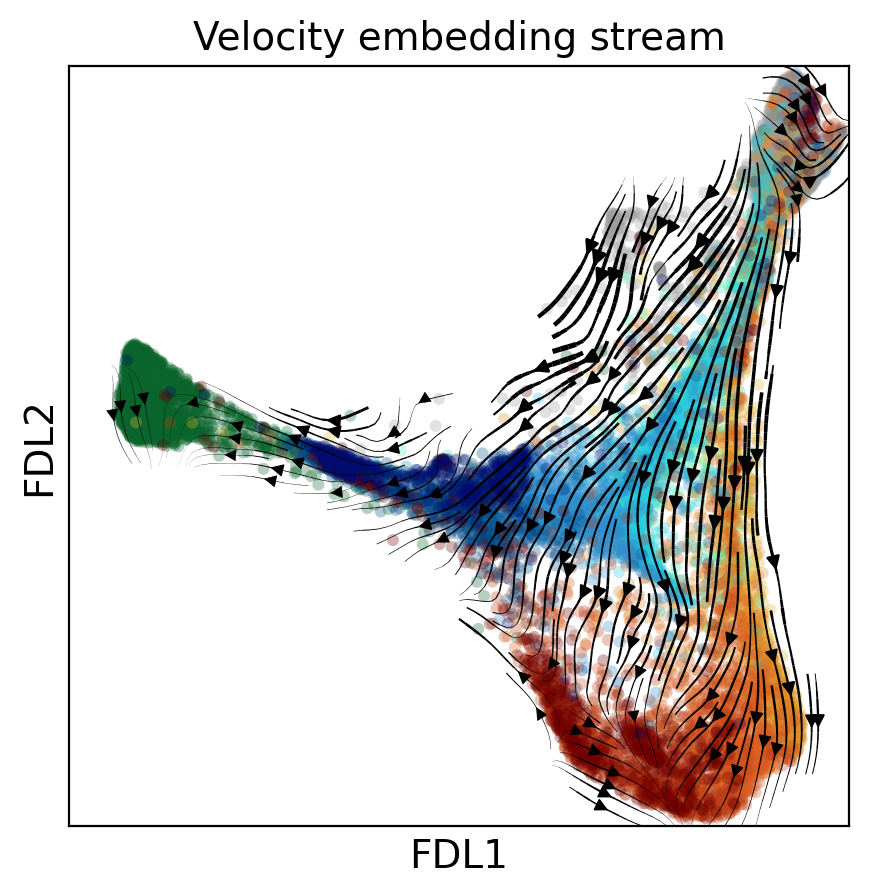

In [36]:
axis = scvelo.pl.velocity_embedding_stream(adata, vkey="sde_velocity", basis="fdl", color="sample", legend_loc="right", dpi=100,
                                           title="Velocity embedding stream", density=3, frameon=True, show=False,
                                           arrow_size=1, figsize=(5,5))
axis.grid(False)
axis.get_legend().remove()
axis.set_xlabel("FDL1")
axis.set_ylabel("FDL2")
figure = pyplot.gcf()
figure.savefig("Graphs/velocity_stream.png", bbox_inches="tight", dpi=300)
pyplot.show()

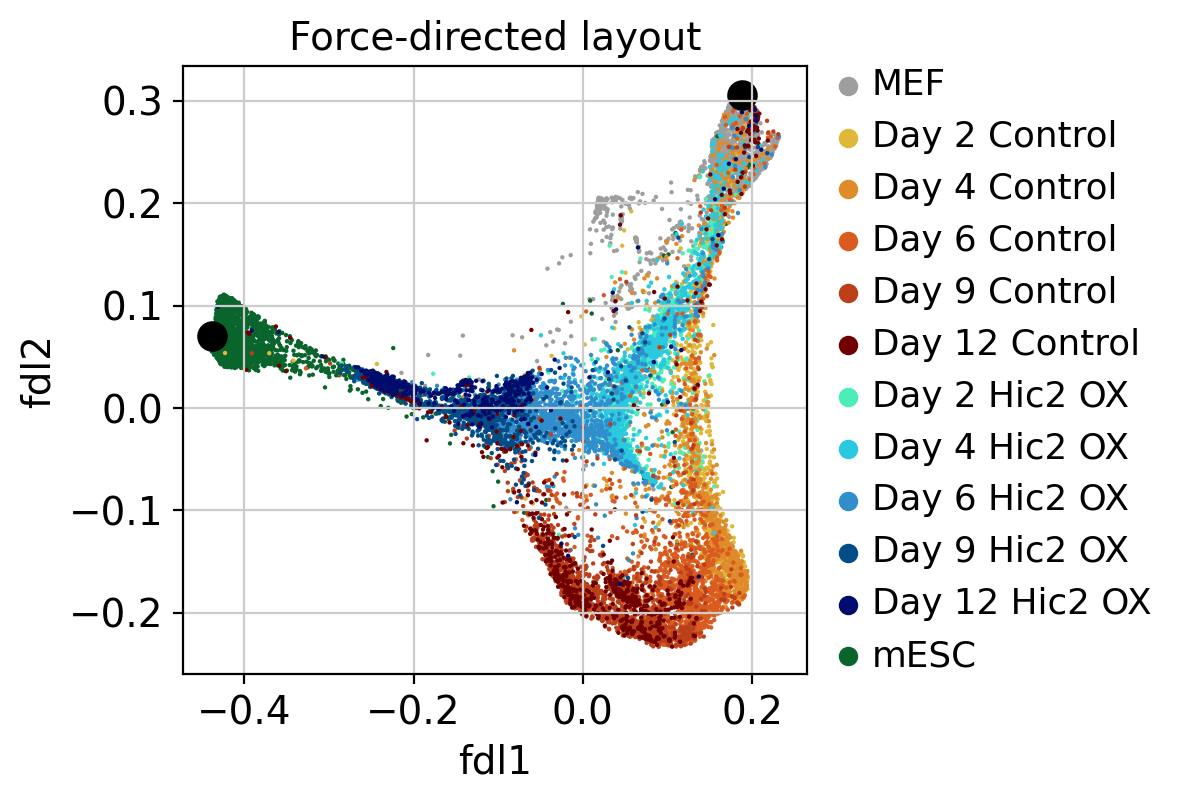

In [39]:
# Find good root and end cells

# Find root
root_filter = (adata.obs["group"]=="MEF")
# Use MEF cell with largest UMAP2, ignoring outliers with >10
root_index = numpy.argmax(adata[root_filter].obsm["X_fdl"][:,1])
root_barcode = adata[root_filter].obs.index[root_index]
adata.obs["manual_root"] = False
adata.obs["manual_root"].loc[root_barcode] = True

# Find end
end_filter = adata.obs["group"]=="mESC"
# Use mESC cell with smallest UMAP1
end_index = numpy.argmin(adata[end_filter].obsm["X_fdl"][:,0])
end_barcode = adata[end_filter].obs.index[end_index]
adata.obs["manual_end"] = False
adata.obs["manual_end"].loc[end_barcode] = True

axis = scanpy.pl.embedding(basis='fdl', adata=adata, color="sample", size=10, title="Force-directed layout", show=False)

# Plot UMAP
axis.scatter(*adata[adata.obs["manual_end"]].obsm["X_fdl"][0], marker="o", s=100, color="black")
axis.scatter(*adata[adata.obs["manual_root"]].obsm["X_fdl"][0], marker="o", s=100, color="black")
axis.yaxis.set_major_locator(matplotlib.ticker.AutoLocator())
axis.xaxis.set_major_locator(matplotlib.ticker.AutoLocator())

pyplot.show()

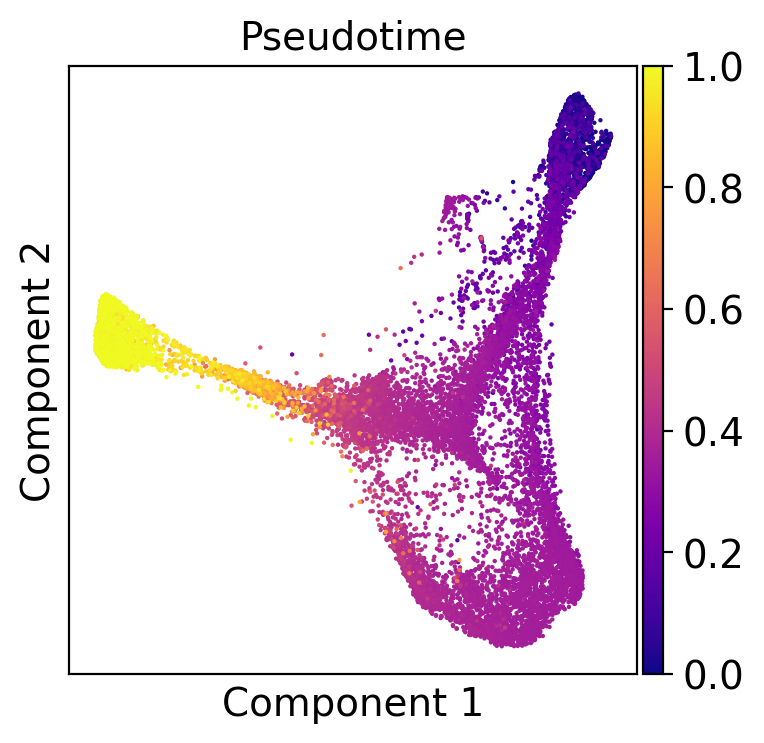

In [42]:
# Pseudotime
global_root_index = numpy.argmax(adata.obs.index == root_barcode)
global_end_index = numpy.argmax(adata.obs.index == end_barcode)

scvelo.tl.velocity_pseudotime(adata, root_key=global_root_index, end_key=global_end_index, vkey="sde_velocity")

# Plot velocities colored by latent time
axis = scanpy.pl.embedding(basis='fdl', adata=adata, color=["sde_velocity_pseudotime"], size=10, title=["Pseudotime", "Sample"], show=False)
axis.set_xlabel("Component 1")
axis.set_ylabel("Component 2")
pyplot.show()

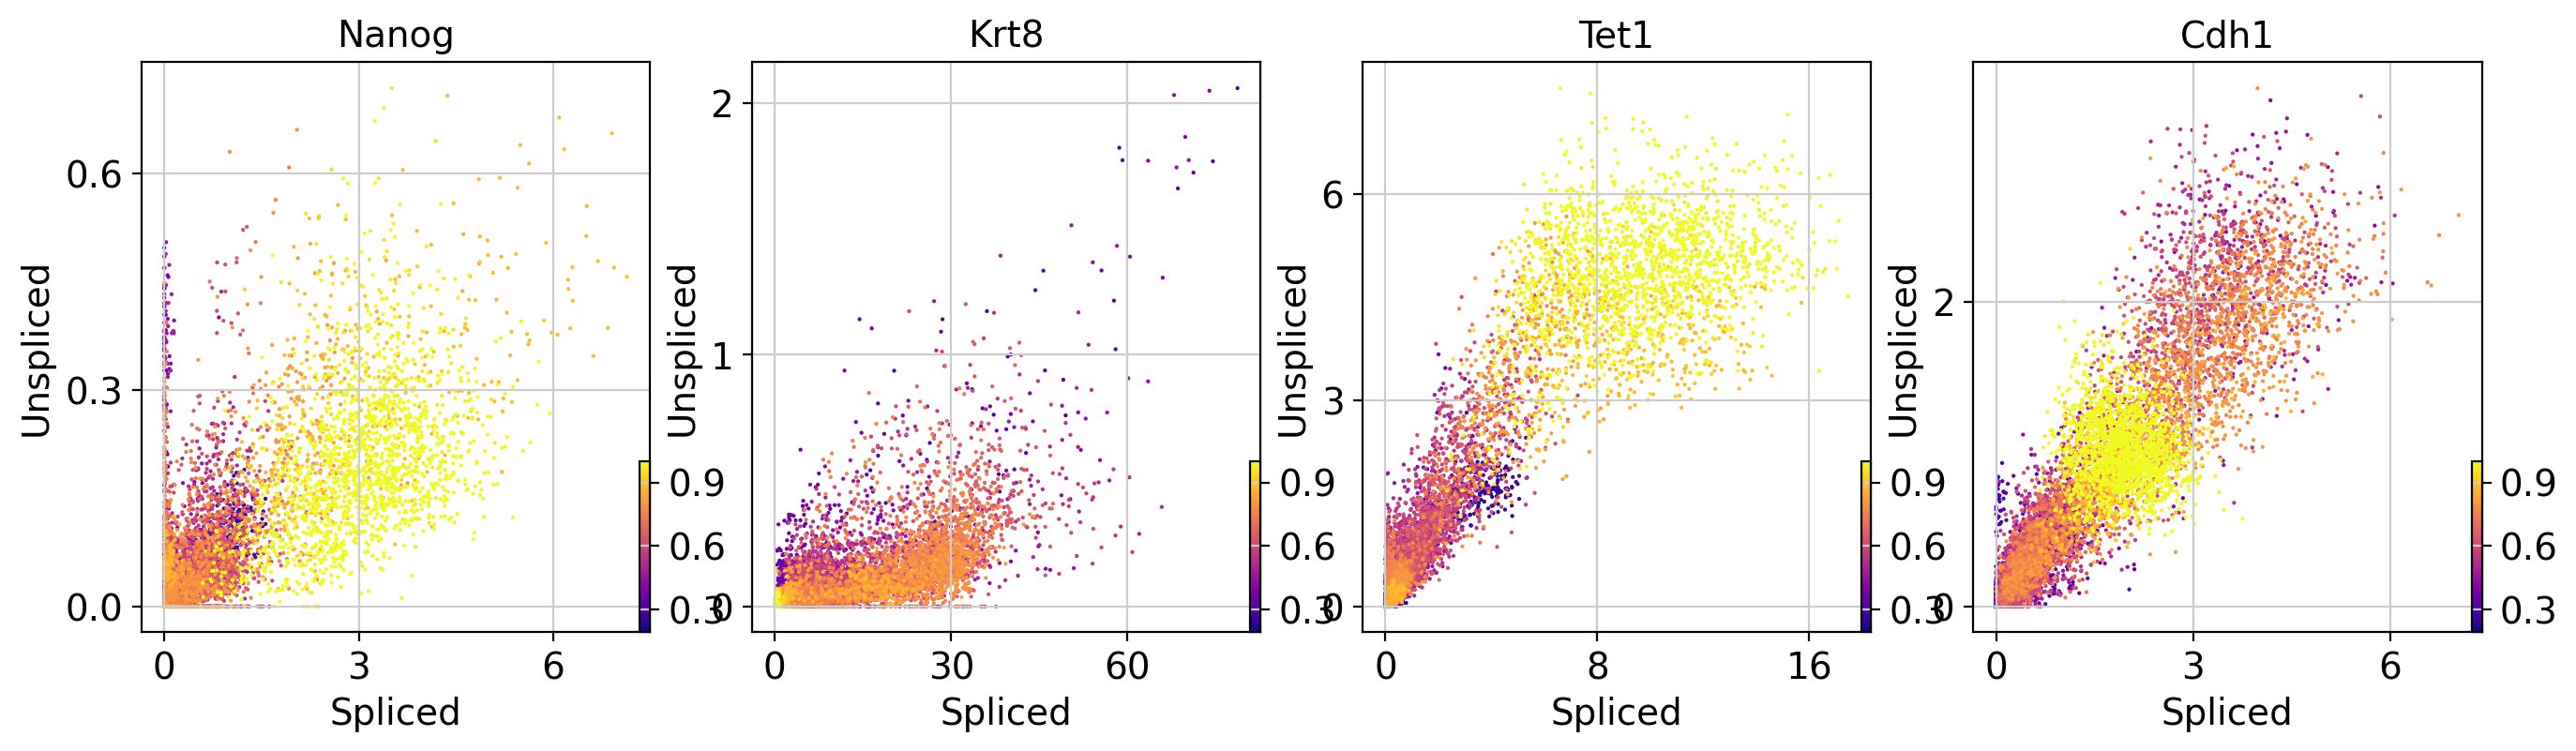

In [43]:
# Plot latent time for specific genes
genes_of_interest = ["Nanog", "Krt8", "Tet1", "Cdh1"]
scvelo.pl.scatter(adata, basis=genes_of_interest, color=["latent_time"], frameon=True, vkey="sde_velocity", xlabel="Spliced", ylabel="Unspliced")

In [80]:
# Save adata object
adata.write_h5ad(
    working_directory+"/velocity_sdevelo.h5ad",
    compression=hdf5plugin.FILTERS["zstd"]
)

In [32]:
# Show that longer training does not reduce loss

adata_longer_training = adata.copy()

model = sdevelo.SDENN(args, adata)
adata = model.train(1000)

cuda
Filtered out 37 genes that are detected 20 counts (shared).
Skip filtering by dispersion since number of variables are less than `n_top_genes`.


/home/avesta/m26_losu/miniconda3/envs/velocity/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.
Using scVelo version 0.3.3
computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
5000
Epoch: 0, Loss: 0.842, alpha: 12.79, beta: 11.04, gamma: 0.94, s1: 0.010, s2: 0.010,  t_m: 0.650,  u_shift: 0.000,  s_shift: -0.012
Epoch: 50, Loss: 0.634, alpha: 5.39, beta: 9.56, gamma: 1.64, s1: 0.016, s2: 0.010,  t_m: 0.734,  u_shift: 0.000,  s_shift: -0.046
Epoch: 100, Loss: 0.505, alpha: 16.07, beta: 26.32, gamma: 7.80, s1: 0.012, s2: 0.010,  t_m: 0.728,  u_shift: 0.000,  s_shift: -0.007
Epoch: 150, Loss: 0.453, alpha: 25.16, beta: 43.81, gamma: 12.77, s1: 0.010, s2: 0.017,  t_m: 0.789,  u_shift: 0.000,  s_shift: 0.065
Epoch: 200, Loss: 0.409, alpha: 35.00, beta: 61.31, gamma: 17.53, s1: 0.010, s2: 0.026,  t_m: 0.812,  u_shift: 0.000,  s_shift: 0.100
Epoch: 250, Loss: 0.388, alpha: 36.03, beta: 63.45, gamma: 18.08, s1: 0.022, s2: 0.010,  t_m: 0.816,  u_shift: 0.000,  s_shift: 0.100
Epoch: 30

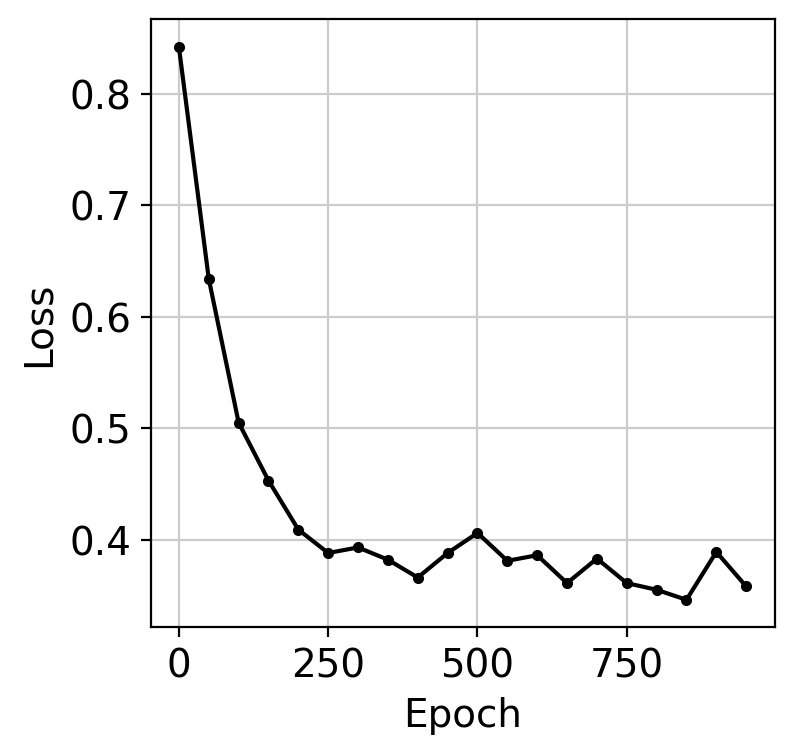

In [48]:
# Plot training history

epoch_list = numpy.arange(0, 951, 50)
loss_list = losses = [
    0.842, 0.634, 0.505, 0.453, 0.409, 
    0.388, 0.393, 0.382, 0.366, 0.388, 
    0.406, 0.381, 0.386, 0.361, 0.383, 
    0.361, 0.355, 0.346, 0.389, 0.358
]

figure, axis = pyplot.subplots()
axis.plot(epoch_list, loss_list, color="black", linestyle="solid", marker=".")
axis.grid(True)
axis.set_xlabel("Epoch")
axis.set_ylabel("Loss")
figure = pyplot.gcf()
figure.savefig("Graphs/sdevelo_training_history.png", bbox_inches="tight", dpi=300)
pyplot.show()